# Data Drift Detection for Bike Demand

**Question:** When should a demand-estimation model be updated, and can input-distribution monitoring alone identify deterioration?

We build a chronological demand model, monitor input distributions and labeled error separately, run known-change stress tests, and compare frozen, scheduled, and performance-triggered updates. All figures and tables below are generated by the code.

Data: [UCI Bike Sharing](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset), [DOI 10.24432/C5W894](https://doi.org/10.24432/C5W894), CC BY 4.0. See `docs/data.md` for provenance and timing.

In [1]:
import os
for key in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS'):
    os.environ[key] = '1'
import sys, json
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src/drift_detection').exists(), 'Run this notebook from the extracted repository.'
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
from scipy.stats import spearmanr
from drift_detection.data import load_hourly, partition, complete_weeks, FEATURES, TARGET
from drift_detection.models import select_model, predict, error_metrics
from drift_detection.metrics import MONITORED_NUMERIC, MONITORED_CATEGORICAL
from drift_detection.monitoring import calibrate, weekly_report, mark_alerts, Thresholds
from drift_detection.experiments import evaluate_controlled, summarize_experiments
from drift_detection.policies import compare_policies
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})
FIGURES = ROOT / 'reports/figures'
FIGURES.mkdir(parents=True, exist_ok=True)
def show(fig, name):
    fig.savefig(FIGURES / f'{name}.png', dpi=150, bbox_inches='tight')
    display(Image(filename=str(FIGURES / f'{name}.png')))
    plt.close(fig)

## 1. Data audit and chronological design

The target is hourly total rentals. Weather measurements are contemporaneous: this is demand estimation **given observed weather**, rather than a forecast made before weather is known. The offline simulator predicts each weekly batch before revealing its targets, then makes those targets available at the batch end.

`casual` and `registered` sum to the target and are excluded. Calendar identifiers `instant` and `yr` are also excluded. Missing hourly records remain absent; they are never treated as zero demand.

Training: January–September 2011. Model selection: October. Threshold calibration: November–December. Monitoring: 2012. Weekly monitoring requires a Monday–Sunday interval inside the partition date span and at least 100 observed hours. Coverage is reported explicitly.

In [2]:
raw_path = ROOT / 'data/raw/hour.csv'
if not raw_path.exists():
    raise FileNotFoundError('Run python scripts/download_data.py first.')
frame = load_hourly(raw_path)
parts = partition(frame)
train, selection, calibration, monitoring = (parts[k] for k in ('train', 'selection', 'calibration', 'monitoring'))
audit = pd.DataFrame([{'partition': k, 'rows': len(v), 'first': v.timestamp.min(), 'last': v.timestamp.max(),
                       'eligible_weeks': len(list(complete_weeks(v))),
                       'eligible_hours': sum(len(b) for _, b in complete_weeks(v))} for k, v in parts.items()])
audit['excluded_hours'] = audit.rows - audit.eligible_hours
display(audit)
assert len(frame) == 17379
assert train.timestamp.max() < selection.timestamp.min() < calibration.timestamp.min() < monitoring.timestamp.min()
assert not set(FEATURES).intersection({'cnt', 'casual', 'registered', 'instant', 'yr'})
print('Absent hourly timestamps within the overall date span:', len(pd.date_range(frame.timestamp.min(), frame.timestamp.max(), freq='h')) - len(frame))

Absent hourly timestamps within the overall date span: 165


,partition,rows,first,last,eligible_weeks,eligible_hours,excluded_hours
0,train,6442,2011-01-01,2011-09-30 23:00:00,38,6275,167
1,selection,743,2011-10-01,2011-10-31 23:00:00,4,671,72
2,calibration,1460,2011-11-01,2011-12-31 23:00:00,7,1174,286
3,monitoring,8734,2012-01-01,2012-12-31 23:00:00,52,8686,48


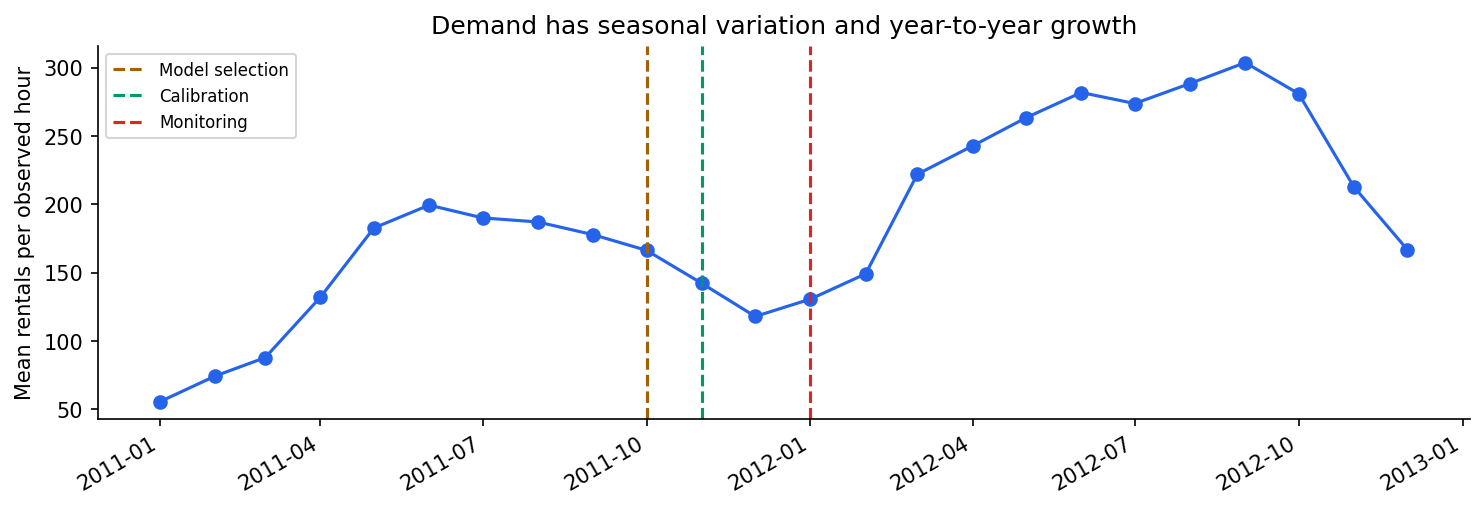

In [3]:
monthly = frame.groupby(frame.timestamp.dt.to_period('M')).cnt.mean()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(monthly.index.to_timestamp(), monthly.values, marker='o', color='#2563eb')
for date, label, color in [('2011-10-01', 'Model selection', '#a16207'), ('2011-11-01', 'Calibration', '#059669'), ('2012-01-01', 'Monitoring', '#dc2626')]:
    ax.axvline(pd.Timestamp(date), color=color, linestyle='--', label=label)
ax.set(title='Demand has seasonal variation and year-to-year growth', ylabel='Mean rentals per observed hour')
ax.legend(loc='upper left', fontsize=8); fig.autofmt_xdate(); fig.tight_layout()
show(fig, '01_demand_chronology')

## 2. Fit the prediction model

A mean predictor provides a simple baseline. Two histogram gradient boosting configurations are fitted on training data only; October MAE selects tree complexity. Numeric weather and categorical calendar features are passed to the model directly. We freeze the selected model before threshold calibration and 2012 evaluation.

MAE measures typical absolute error in rentals per hour; RMSE gives more weight to large misses. No percentage-error metric is used because low-demand hours would make it unstable.

In [4]:
model, leaves, model_scores = select_model(train, selection)
display(model_scores.round(3))
print('Selected maximum leaves:', leaves)
print('Calibration overall error:', error_metrics(calibration.cnt, predict(model, calibration)))

Selected maximum leaves: 31
Calibration overall error: {'mae': 34.965187788842734, 'rmse': 52.5609424301981}


,model,mae,rmse
0,boosting_31_leaves,29.702,43.040
1,boosting_15_leaves,32.416,44.713
2,mean_baseline,114.600,146.506


## 3. Distribution and error monitoring

For temperature, feels-like temperature, humidity, and wind speed, calculate KS statistics, reference-quantile PSI, and Wasserstein distance divided by the training IQR (with a scale fallback for constant features). For weather condition and working-day status, calculate total variation distance, including unseen categories.

The input score is the equal-weight mean of four normalized Wasserstein distances and two total variation distances. Its features, reference, and weights stay fixed. It is a heuristic score, not a probability. Calendar month/hour are model predictors but are omitted from monitoring to avoid alarms caused solely by known calendar progression; weather seasonality can still cause alerts.

KS p-values are descriptive: serial dependence and repeated testing invalidate a simple interpretation as a production alert rule. Conventional PSI cutoffs are not assumed.

Thresholds are empirical 95th percentiles of **200 synthetic no-change weeks**, built by resampling whole days from the calibration period (seed 9001). This retains within-day dependence but not dependence across days. Evaluation uses different random seeds. Error alerts require two adjacent weekly MAE exceedances. This calibration represents the November–December baseline and does not guarantee a 5% false-alarm rate in other seasons.

In [5]:
cuts, calibration_weeks = calibrate(train, calibration, model, bootstrap_weeks=200)
naive_cuts = Thresholds(float(np.quantile(calibration_weeks.drift_score, .95, method='higher')),
                        float(np.quantile(calibration_weeks.mae, .95, method='higher')))
display(pd.DataFrame([{'method': 'Observed calibration weeks only', 'input_cutoff': naive_cuts.covariate, 'MAE_cutoff': naive_cuts.error},
                     {'method': '200 day-resampled calibration weeks', 'input_cutoff': cuts.covariate, 'MAE_cutoff': cuts.error}]).round(4))
print('Observed eligible calibration weeks:', len(calibration_weeks))
natural, feature_history = weekly_report(train, monitoring, model)
natural = mark_alerts(natural, cuts)
display(natural[['week', 'n', 'drift_score', 'mae', 'covariate_alert', 'performance_alert']].head())
print('Input-alert weeks:', int(natural.covariate_alert.sum()), '/', len(natural))
print('Performance-alert weeks:', int(natural.performance_alert.sum()), '/', len(natural))
display(natural.loc[natural.n < 160, ['week', 'n', 'mae']])

Observed eligible calibration weeks: 7
Input-alert weeks: 7 / 52
Performance-alert weeks: 50 / 52


,method,input_cutoff,MAE_cutoff
0,Observed calibration weeks only,0.2858,51.9513
1,200 day-resampled calibration weeks,0.3277,46.5454


,week,n,drift_score,mae,covariate_alert,performance_alert
0,2012-01-02,167,0.388928,61.635146,True,False
1,2012-01-09,167,0.280911,63.467713,False,True
2,2012-01-16,167,0.399358,57.087908,True,True
3,2012-01-23,168,0.268198,89.730077,False,True
4,2012-01-30,168,0.243431,78.703375,False,True


,week,n,mae
43,2012-10-29,132,88.646447


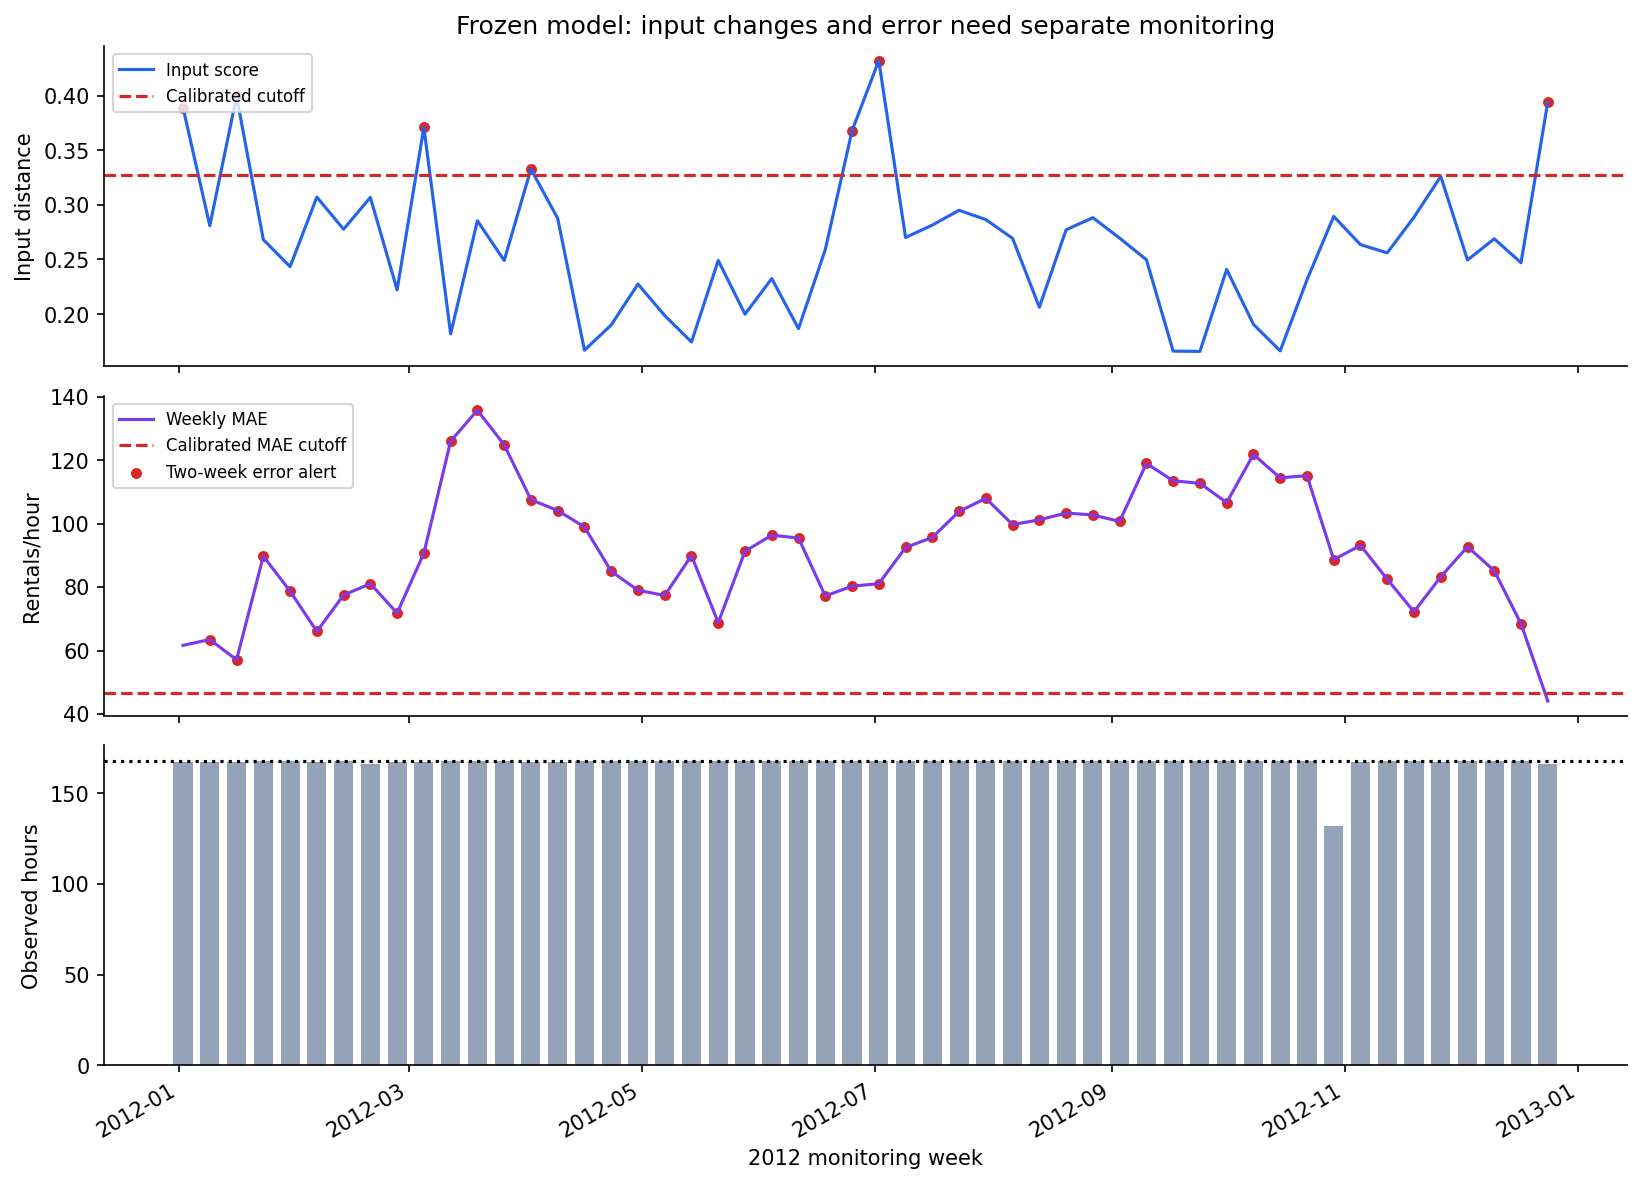

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(natural.week, natural.drift_score, color='#2563eb', label='Input score')
axes[0].axhline(cuts.covariate, color='#dc2626', linestyle='--', label='Calibrated cutoff')
axes[0].scatter(natural.loc[natural.covariate_alert, 'week'], natural.loc[natural.covariate_alert, 'drift_score'], color='#dc2626', s=18)
axes[0].set(ylabel='Input distance', title='Frozen model: input changes and error need separate monitoring')
axes[0].legend(loc='upper left', fontsize=8)
axes[1].plot(natural.week, natural.mae, color='#7c3aed', label='Weekly MAE')
axes[1].axhline(cuts.error, color='#dc2626', linestyle='--', label='Calibrated MAE cutoff')
axes[1].scatter(natural.loc[natural.performance_alert, 'week'], natural.loc[natural.performance_alert, 'mae'], color='#dc2626', s=18, label='Two-week error alert')
axes[1].set(ylabel='Rentals/hour'); axes[1].legend(loc='upper left', fontsize=8)
axes[2].bar(natural.week, natural.n, width=5, color='#94a3b8')
axes[2].axhline(168, linestyle=':', color='black'); axes[2].set(ylabel='Observed hours', xlabel='2012 monitoring week')
fig.autofmt_xdate(); fig.tight_layout(); show(fig, '02_weekly_monitoring')

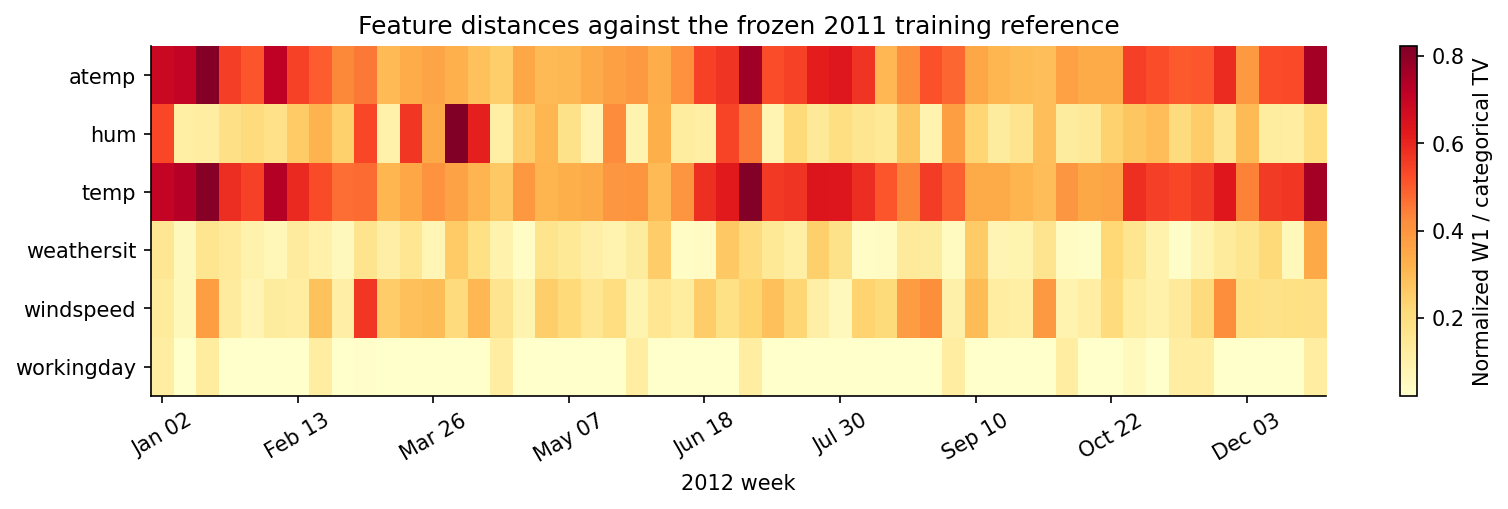

,distance,psi,ks_statistic
feature,,,
atemp,0.466,2.281,0.478
hum,0.250,0.491,0.205
temp,0.493,2.312,0.483
weathersit,0.129,NaN,NaN
windspeed,0.201,0.214,0.152
workingday,0.044,NaN,NaN


In [7]:
distance_matrix = feature_history.pivot(index='feature', columns='week', values='distance')
fig, ax = plt.subplots(figsize=(11, 3.5))
image = ax.imshow(distance_matrix.to_numpy(), aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(distance_matrix)), distance_matrix.index)
ticks = np.arange(0, len(distance_matrix.columns), 6)
ax.set_xticks(ticks, [distance_matrix.columns[i].strftime('%b %d') for i in ticks], rotation=30)
ax.set(title='Feature distances against the frozen 2011 training reference', xlabel='2012 week')
fig.colorbar(image, ax=ax, label='Normalized W1 / categorical TV')
fig.tight_layout(); show(fig, '03_feature_distances')
display(feature_history.groupby('feature')[['distance', 'psi', 'ks_statistic']].mean().round(3))

Descriptive Spearman correlation: -0.351; no causal interpretation or independent-observation p-value claim.


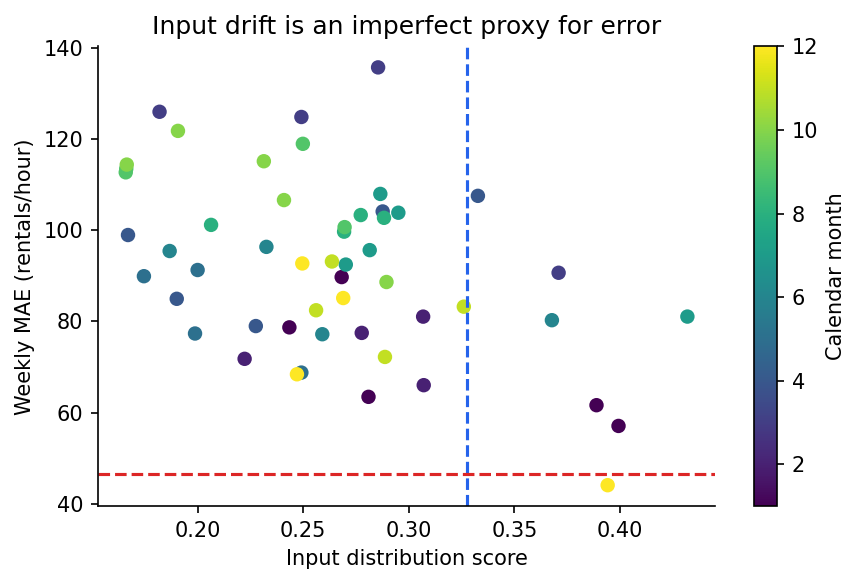

In [8]:
correlation = spearmanr(natural.drift_score, natural.mae)
fig, ax = plt.subplots(figsize=(6, 4))
points = ax.scatter(natural.drift_score, natural.mae, c=natural.week.dt.month, cmap='viridis', s=35)
ax.axvline(cuts.covariate, linestyle='--', color='#2563eb'); ax.axhline(cuts.error, linestyle='--', color='#dc2626')
ax.set(xlabel='Input distribution score', ylabel='Weekly MAE (rentals/hour)', title='Input drift is an imperfect proxy for error')
fig.colorbar(points, ax=ax, label='Calendar month')
fig.tight_layout(); show(fig, '04_distance_vs_error')
print(f'Descriptive Spearman correlation: {correlation.statistic:.3f}; no causal interpretation or independent-observation p-value claim.')

## 4. Evaluate known changes with paired synthetic streams

Run 20 seeds for each scenario, 40 weeks per stream, with an injection after 20 baseline weeks. Each week consists of seven calibration days sampled with replacement. Identical seeds make scenario comparisons paired.

- **No change:** no injection. This estimates alerts under the resampled calibration baseline, rather than false alarms across all real-world seasons.
- **Sensor bias:** reported temperature and feels-like temperature fall by 0.20 normalized units; humidity rises by 0.35, clipped to [0,1]. Rentals remain unchanged. This represents input measurement corruption, not a causal weather experiment.
- **Demand growth:** rental labels are multiplied by 1.6, rounded to counts. Inputs remain exactly unchanged. This changes conditional demand and illustrates why input monitoring alone cannot identify every performance failure.

An alert after the nominal onset in the no-change scenario is still a false alert. `runs_with_postonset_alert` reports at least one alert over 20 weeks; it is not per-week sensitivity. Delay is the number of later batches after the first affected batch, conditional on an alert. A delay of zero means an alert at the end of the first affected batch. These are stress tests, not known drift labels for 2012.

In [9]:
experiment_results, traces = evaluate_controlled(train, calibration, model, cuts, seeds=range(20))
experiment_summary = summarize_experiments(experiment_results)
display(experiment_summary.round(3))
# Conditional-demand changes have identical inputs, and therefore identical input alerts.
assert np.array_equal(traces['no_change'].covariate_alert, traces['demand_growth'].covariate_alert)
for scenario, trace in traces.items():
    assert len(trace) == 40
print('Paired no-change / demand-growth input-alert sequences are identical.')

Paired no-change / demand-growth input-alert sequences are identical.


,scenario,detector,prechange_alert_fraction,runs_with_postonset_alert,postonset_alert_fraction,median_delay_batches,all_alert_fraction
0,demand_growth,covariate_alert,0.075,0.60,0.055,5.0,0.065
1,demand_growth,performance_alert,0.008,1.00,0.957,1.0,0.483
2,no_change,covariate_alert,0.075,0.60,0.055,5.0,0.065
3,no_change,performance_alert,0.008,0.05,0.002,2.0,0.005
4,sensor_bias,covariate_alert,0.075,1.00,1.000,0.0,0.538
5,sensor_bias,performance_alert,0.008,1.00,0.642,1.0,0.325


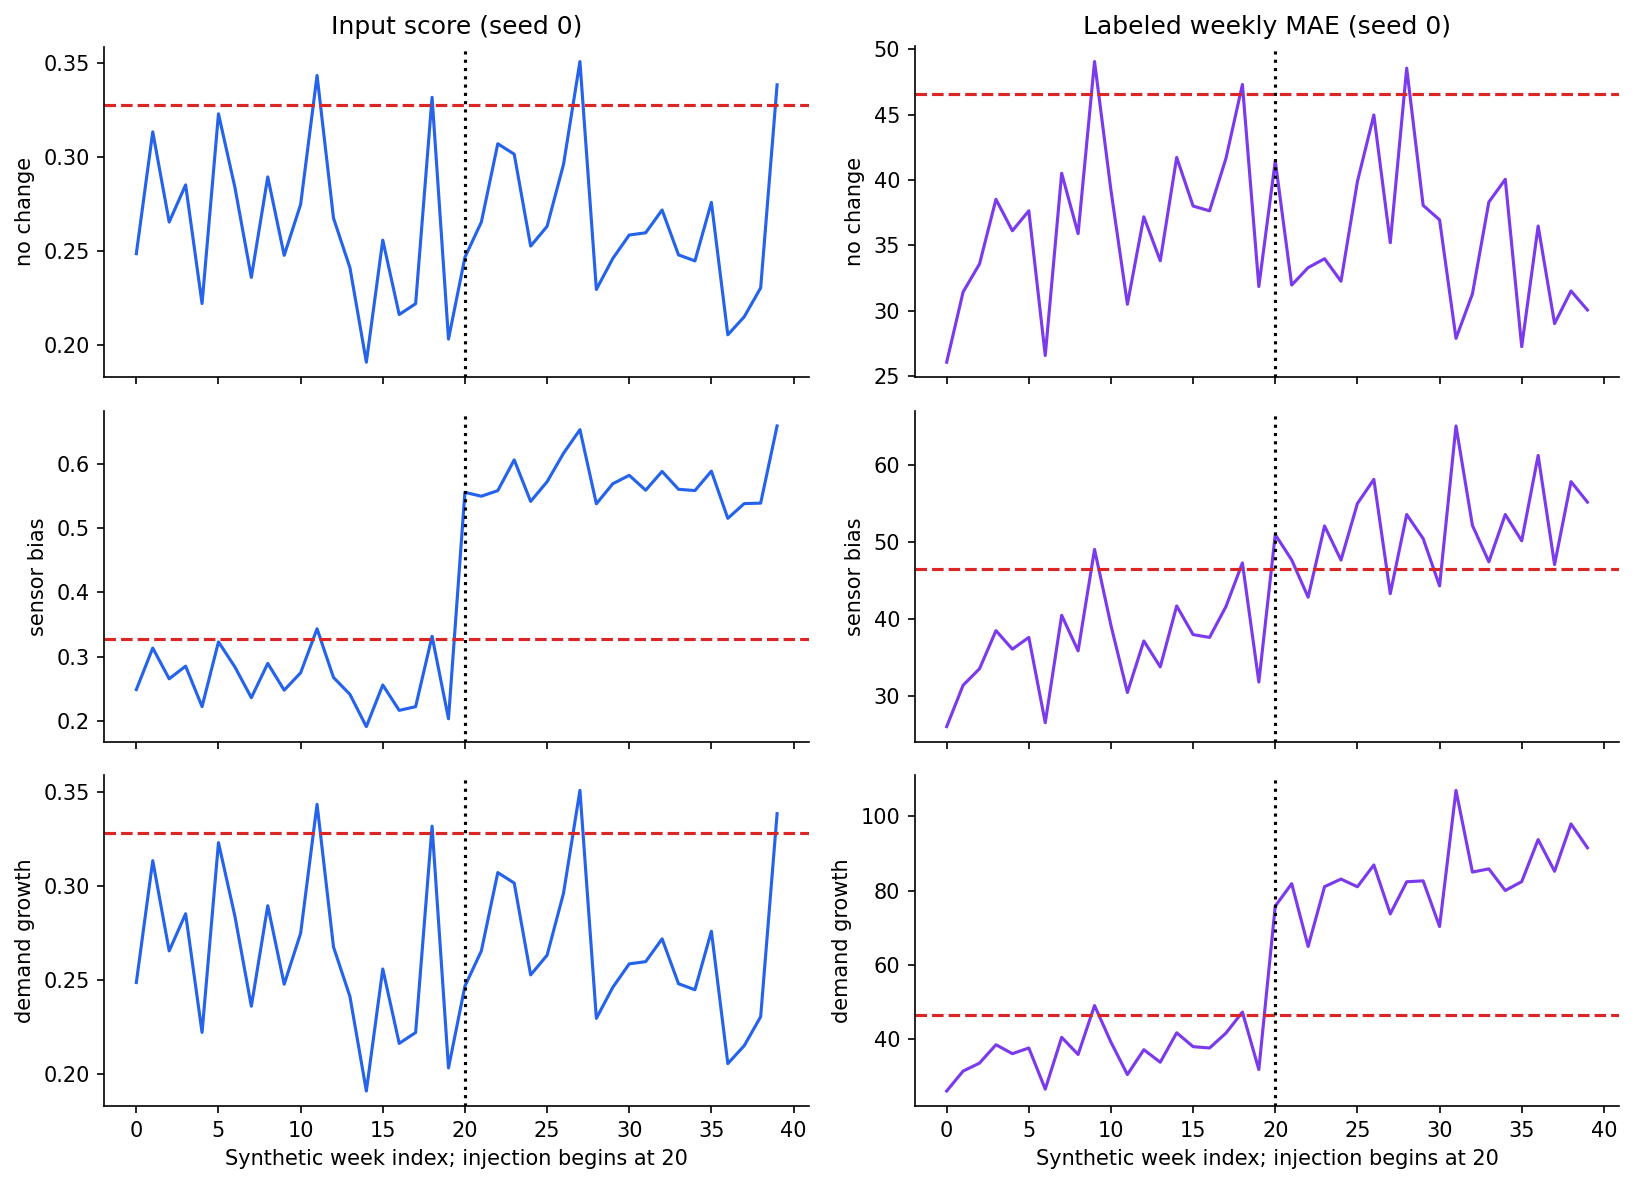

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True)
for row, scenario in enumerate(['no_change', 'sensor_bias', 'demand_growth']):
    trace = traces[scenario]
    axes[row, 0].plot(range(40), trace.drift_score, color='#2563eb')
    axes[row, 0].axhline(cuts.covariate, color='#dc2626', linestyle='--')
    axes[row, 1].plot(range(40), trace.mae, color='#7c3aed')
    axes[row, 1].axhline(cuts.error, color='#dc2626', linestyle='--')
    for ax in axes[row]:
        ax.axvline(20, color='black', linestyle=':'); ax.set_ylabel(scenario.replace('_', ' '))
axes[0, 0].set_title('Input score (seed 0)'); axes[0, 1].set_title('Labeled weekly MAE (seed 0)')
for ax in axes[-1]: ax.set_xlabel('Synthetic week index; injection begins at 20')
fig.tight_layout(); show(fig, '05_controlled_shift_traces')

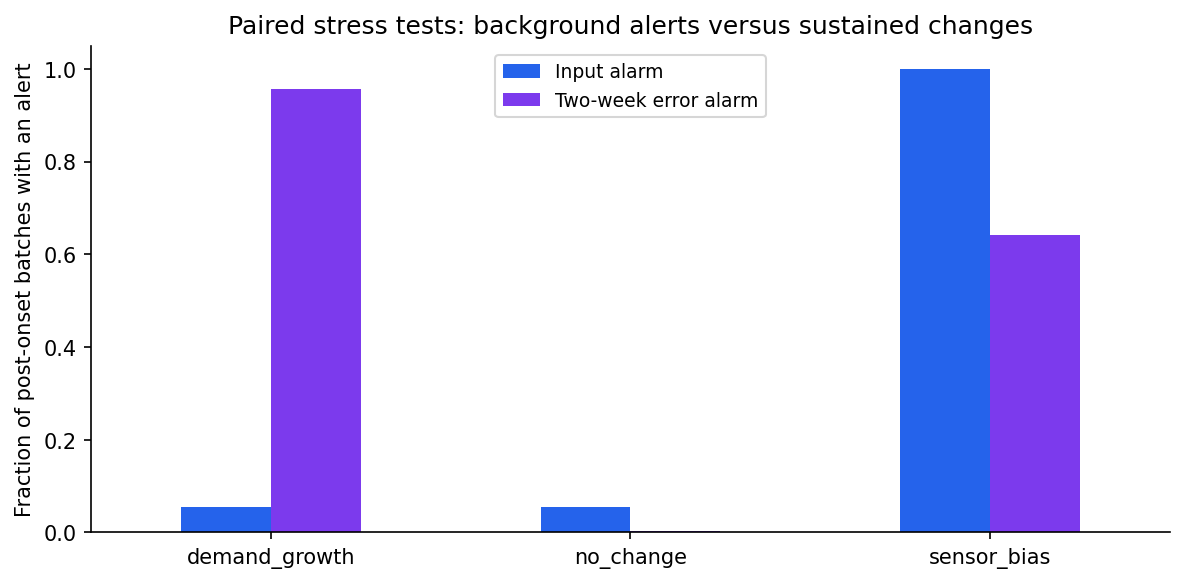

In [11]:
pivot = experiment_summary.pivot(index='scenario', columns='detector', values='postonset_alert_fraction')
fig, ax = plt.subplots(figsize=(8, 4))
pivot.rename(columns={'covariate_alert': 'Input alarm', 'performance_alert': 'Two-week error alarm'}).plot.bar(ax=ax, color=['#2563eb', '#7c3aed'])
ax.set(ylabel='Fraction of post-onset batches with an alert', xlabel='', ylim=(0, 1.05), title='Paired stress tests: background alerts versus sustained changes')
ax.tick_params(axis='x', rotation=0); ax.legend(fontsize=9)
fig.tight_layout(); show(fig, '06_controlled_alarm_rates')

## 5. Compare retraining policies

Every policy starts with the same selected model. Each batch is predicted before its labels are used. Updates use a trailing 180-day window of available observations and affect the **next** batch.

- Frozen: no updates.
- Scheduled: update after every four completed batches.
- Error-triggered: update after two consecutive weekly MAE exceedances, with at least four batches between updates.

All 2011 labels are available for later update windows, including selection/calibration periods. They do not enter the initial model fit. Initial thresholds remain fixed so the policies are directly comparable. No update is charged after the final batch because it could not affect an evaluated prediction. Error is pooled over hourly observations, rather than an unweighted mean of weekly errors. Fit counts exclude the common initial fit.

A labeled-error trigger reacts after losses have been observed. There is no claim that it anticipates every failure or is always better than scheduled updates.

In [12]:
available_history = frame.loc[frame.timestamp < '2012-01-01'].copy()
policy_summary, policy_weeks, policy_observations = compare_policies(train, monitoring, model, leaves, cuts, available_history=available_history)
display(policy_summary.round(3))
assert policy_summary.evaluated_hours.nunique() == 1
assert policy_summary.loc[policy_summary.policy == 'frozen', 'update_fits'].iloc[0] == 0
frozen_obs = policy_observations.loc[policy_observations.policy == 'frozen']
assert np.isclose(error_metrics(frozen_obs.actual, frozen_obs.prediction)['mae'], np.average(natural.mae, weights=natural.n))
updates = policy_weeks.loc[policy_weeks.retrained_after_batch]
assert ((updates.latest_label_used_if_updated >= updates.week) & (updates.latest_label_used_if_updated < updates.week + pd.Timedelta(days=7))).all()
print('Update time boundaries and frozen-model agreement verified.')

Update time boundaries and frozen-model agreement verified.


,policy,mae,rmse,update_fits,evaluated_hours
0,frozen,91.907,128.051,0,8686
1,scheduled,51.459,79.785,12,8686
2,error_triggered,52.321,81.741,7,8686


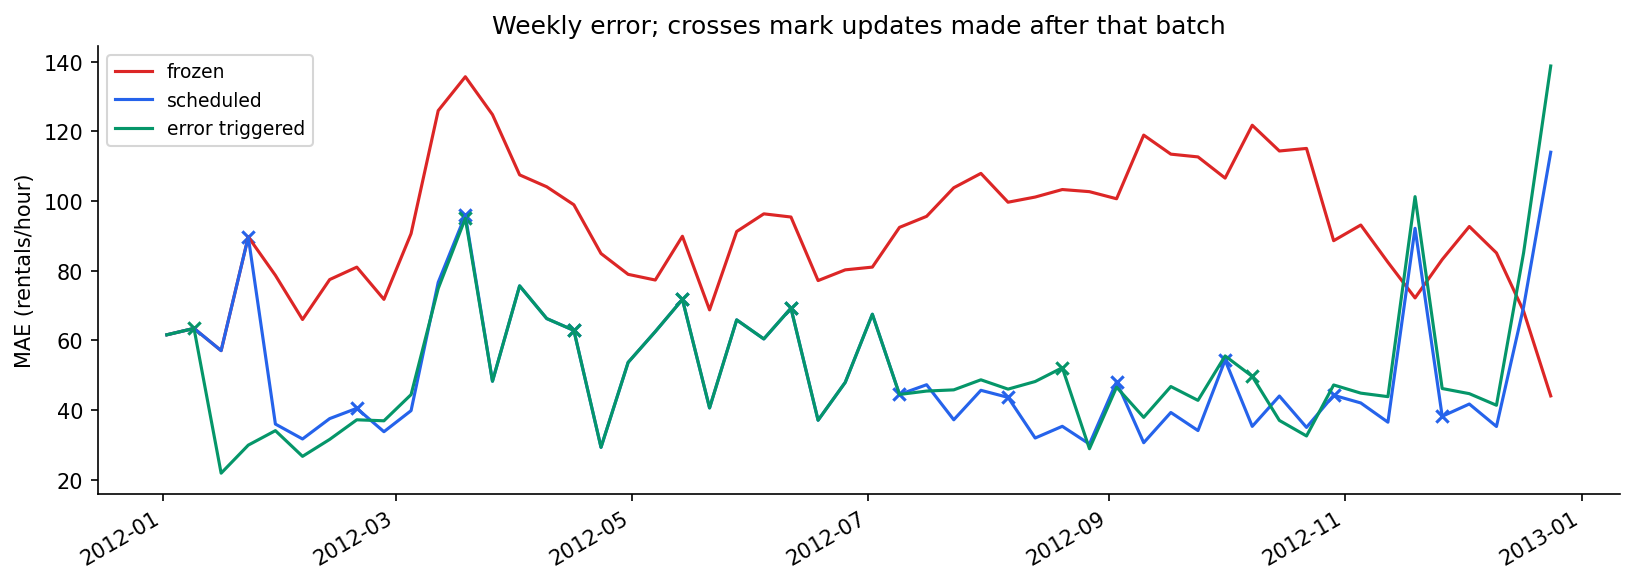

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
colors = {'frozen': '#dc2626', 'scheduled': '#2563eb', 'error_triggered': '#059669'}
for name, group in policy_weeks.groupby('policy', sort=False):
    ax.plot(group.week, group.mae, label=name.replace('_', ' '), color=colors[name])
    updated = group.loc[group.retrained_after_batch]
    ax.scatter(updated.week, updated.mae, color=colors[name], marker='x', s=35)
ax.set(title='Weekly error; crosses mark updates made after that batch', ylabel='MAE (rentals/hour)')
ax.legend(fontsize=9); fig.autofmt_xdate(); fig.tight_layout(); show(fig, '07_policy_error_and_updates')

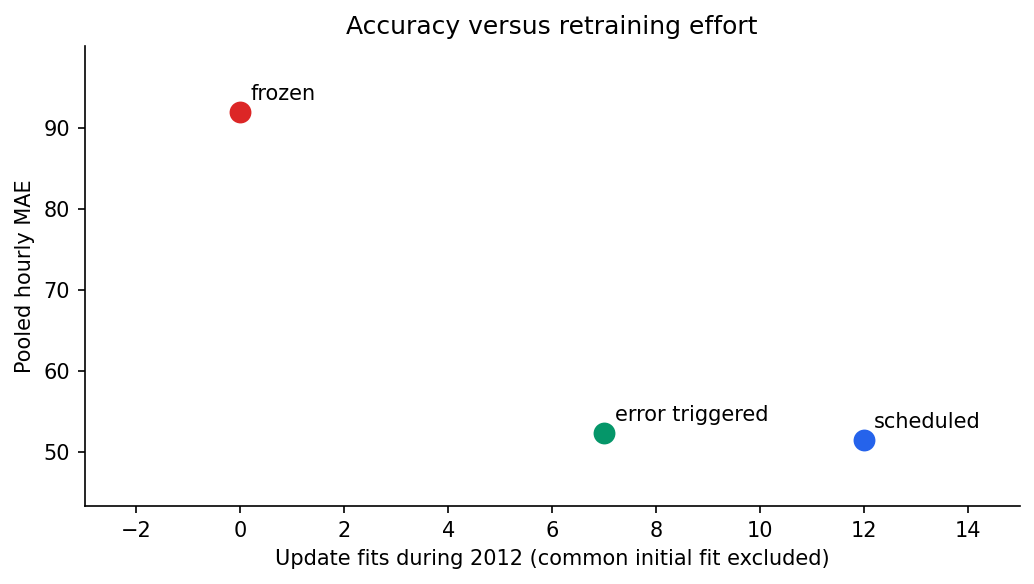

,policy,mae,rmse,update_fits,evaluated_hours,MAE_reduction_vs_frozen_pct
0,frozen,91.907,128.051,0,8686,0.000
1,scheduled,51.459,79.785,12,8686,44.009
2,error_triggered,52.321,81.741,7,8686,43.072


In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
for row in policy_summary.itertuples():
    ax.scatter(row.update_fits, row.mae, color=colors[row.policy], s=90)
    ax.annotate(row.policy.replace('_', ' '), (row.update_fits, row.mae), xytext=(5, 6), textcoords='offset points')
ax.set(xlabel='Update fits during 2012 (common initial fit excluded)', ylabel='Pooled hourly MAE', title='Accuracy versus retraining effort')
ax.margins(x=.25, y=.2); fig.tight_layout(); show(fig, '08_accuracy_vs_fits')
frozen_mae = policy_summary.loc[policy_summary.policy == 'frozen', 'mae'].iloc[0]
policy_summary['MAE_reduction_vs_frozen_pct'] = 100 * (1 - policy_summary.mae / frozen_mae)
display(policy_summary.round(3))

## 6. Save reproducible results

Tables, figures, and configuration are saved to `reports/`. Raw data stay outside Git. Predictions are included as an audit of the offline policy comparison; the notebook can regenerate them from the included/downloaded data.

In [15]:
REPORTS = ROOT / 'reports'
for name, table in [('partition_audit', audit), ('model_selection', model_scores), ('calibration_weeks', calibration_weeks),
                    ('natural_monitoring', natural), ('feature_monitoring', feature_history), ('controlled_runs', experiment_results),
                    ('controlled_summary', experiment_summary), ('policy_summary', policy_summary), ('policy_weeks', policy_weeks),
                    ('policy_predictions', policy_observations)]:
    table.to_csv(REPORTS / f'{name}.csv', index=False)
configuration = {'dataset_rows': len(frame), 'selected_max_leaf_nodes': int(leaves),
                 'input_threshold': cuts.covariate, 'weekly_MAE_threshold': cuts.error,
                 'calibration_bootstrap_weeks': 200, 'calibration_seed': 9001,
                 'experiment_seeds': list(range(20)), 'experiment_weeks': 40, 'injection_week': 20,
                 'monitoring_weeks': len(natural), 'evaluated_hours': int(policy_summary.evaluated_hours.iloc[0]),
                 'history_days': 180, 'scheduled_every_batches': 4, 'cooldown_batches': 4, 'error_patience': 2}
(REPORTS / 'configuration.json').write_text(json.dumps(configuration, indent=2) + '\n')
print('Saved 10 result tables, configuration, and 8 figures.')

Saved 10 result tables, configuration, and 8 figures.


### Observed results

On 8,686 eligible monitoring hours, the frozen model has MAE **91.91**. Scheduled updates reduce MAE to **51.46** with 12 fits; error-triggered updates reach **52.32** with 7 fits. The triggered policy uses fewer updates with slightly higher error than the scheduled policy in this case study.

Across 20 paired seeds, demand growth generates performance alerts in **95.75%** of post-onset batches. Input alerts remain identical to the no-change stream (**5.5%** of post-onset batches). Sensor bias produces an input alert in every post-onset batch, with the first alert in the first affected batch for all 20 streams. No-change input alerts occur in **6.5%** of all simulated batches, demonstrating why an empirical 95th-percentile threshold is not a deployment guarantee.

These numbers describe the prespecified experiments and this dataset; they do not establish universal detector or retraining performance.

## Interpretation and limitations

1. Input changes and rising prediction error describe different events. The paired demand-growth experiment leaves input alerts unchanged; labels are needed to recognize that failure.
2. Both seasonal weather and longer-term demand growth occur in these data. Natural input alarms are not automatically failures, and there are no ground-truth drift dates in 2012; natural-alert precision/recall is not estimated.
3. Calibration uses a short seasonal period. Day resampling preserves intraday structure but breaks day-to-day dependence and can mix weekdays/weather in ways that do not represent actual future weeks. Empirical null results do not guarantee deployment false-alarm rates.
4. The input score tracks only marginal distributions. Changes in feature relationships could be missed. PSI and KS are diagnostics; no multiple-testing or independence guarantee is asserted.
5. Weekly labels and weather are assumed available for this retrospective simulation. Real usage needs label latency, missing-data monitoring, weather forecasts if future-hour prediction is required, and alert routing.
6. Retraining frequency and the 180-day window are prespecified choices, not an optimized global policy. This single dataset supports a case study, not a universal retraining recommendation.

### References

- Fanaee-T, H. (2013), [Bike Sharing, UCI](https://doi.org/10.24432/C5W894).
- SciPy documentation: [KS two-sample test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html), [Wasserstein distance](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wasserstein_distance.html).
- scikit-learn: [HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html), [DummyRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html).

### Extensions

Season-matched reference distributions; explicit monitoring of missingness and feature relationships; performance monitoring stratified by hour/customer type; delayed-label simulation; prospective evaluation on an additional dataset.